#### Group H, Lennard Schulze & Hendrik Higl

# Image reconstruction using probabilistic Principal Component Analysis

## Foreword

####  Principal Component Analysis
Principal Component Analysis (PCA) is the oldest and most common technique for _dimensionality reduction_: we want to represent points $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n$ from a multidimensional space $\mathbb{R}^D$ and _embed_ them into a smaller subspace $\mathbb{R}^M$. The strategy in the case of PCA is to sequentially maximize the variance explained by each subspace $\mathbf{u}_1, \mathbf{u}_2, \ldots, \mathbf{u}_M \in \mathbb{R}^D$. We can represent the approximation of the $\mathbf{x}_i$ by its coordinates in the new system: 
$$
\mathbf{z} = (z_1, \ldots, z_M)^{T} = (\mathbf{u}_1^T \mathbf{x}, \ldots, \mathbf{u}_M^T \mathbf{x})
$$

#### Probabilistic formulation of PCA

An equivalent probabilistic formulation of PCA is to consider a hierarchical model with a latent variable $\mathbf{z} \in \mathbb{R}^M$ drawn from a isotropic gaussian, and then a projection using the matrix $W$ ($I_{D}$ is the identity matrix in $\mathbb{R}^{D\times D}$):
\begin{align*}
\mathbf{z} & \sim \mathcal{N}(0, I_{M}) \\
\mathbf{x} & = W \mathbf{z} + \mu + \varepsilon \\
\varepsilon & \sim \mathcal{N}(0, \sigma^2 I_{D} )
\end{align*}

#### Generalisation of PCA: Latent Factor Analysis
If we take out the hypothesis that the noise is isotropic, we have a model called *Latent Factor Analysis* or *Factor Analysis* (FA), where this time $\varepsilon$ has a diagonal covariance $\Psi$ ($\varepsilon \sim \mathcal{N}(0,\Psi)$). We will use this model in the following or more precisely an extension of it to mixture (mixture of factor analysers).


## Outline of the Project

In this project we will revisit the MNIST dataset using first PCA. We will then move to the probabilistic formulation and consider mixtures of pPCA/FA and see how they allow to embed the image space in a series of components with different dimensions.
We can note that this unsupervised learning approach is complementary another unsupervised learning approach we saw previously. Indeed, in project 3, we applied clustering on the same dataset. We will see how dimensionality reduction provides another way to perform image imputation. 

The project is divided into 4 parts:

1. Data loading and preprocessing.
2. Applying Principal component analysis to the data and evaluation of the approximation.
3. Applying mixtures of probabilistic PCA and Factor Analysis and evaluation of the results for data representation.
4. Using mixture of pPCA/Factor Analysers for image imputation, and compare it with the clustering results (optional)

## 1. Data loading and preprocessing


For this project, it is necessary to install the following packages for data download and for estimating Mixture of Factor analyzers:
- PyTorch 
- PyTorch lightning 

We will also make use of a published module that performed pPCA and LFA for a [paper comparing Generative Adversarial Networks with Gaussian Mixture Models](https://arxiv.org/abs/1805.12462). The original implementation in [tensorflow is here](https://github.com/eitanrich/gans-n-gmms) and the more recent pytorch version can be found [here](https://github.com/eitanrich/torch-mfa). No need to download those modules for the project, as all the necessary functions have been provided in the `mfa_helpers.py` accompanying file.




In [ ]:
!uv pip install pytorch_lightning

In [163]:
from pathlib import Path

from PIL import Image
from matplotlib import pyplot as plt

from torchvision.datasets import MNIST

from mfa_helpers import *

import torchvision.transforms as transforms


torch.manual_seed(666)


### Load and represent the data

We will start by loading the data and normalizing it with the corresponding torch data loader. We will use the torch function to load the data and transform it into flat vectors from the beginning on. Note that in this case we apply Torch functions for reshaping the tensors.


### Preparing dataset

In [164]:

## The transform options reads the data and renormalizes it
## to a one dimensional vector. 

## it is also possible to download the MNIST.zip archive and uncompress it in a data subfolder

train_dataset = MNIST(
    root='./data',
    train=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        ReshapeTransform([-1])
    ]),
    download=True
)
test_dataset = MNIST(
    root='./data',
    train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        ReshapeTransform([-1])
    ]),
    download=True
)





### Plotting functions

We provide below some new plotting functions. Those function are provided as they can be adapted to color images, but you can also use the function from project 3 if you prefer. 


In [165]:

def samples_to_np_images(samples, image_shape=[64, 64, 3], clamp=True):
    assert len(samples.shape) == 2
    assert samples.shape[1] == np.prod(image_shape)
    assert len(image_shape) == 2 or (len(image_shape) == 3 and image_shape[2] > 1)
    samples_out = samples if not clamp else torch.clamp(samples, 0., 1.)
    if len(image_shape) == 3:
        return samples_out.reshape(-1, image_shape[2], image_shape[0], image_shape[1]).permute(0, 2, 3, 1).cpu().numpy()
    else:
        return samples_out.reshape(-1, image_shape[0], image_shape[1]).cpu().numpy()


def sample_to_np_image(sample, image_shape=[64, 64, 3]):
    return samples_to_np_images(sample.unsqueeze(0), image_shape).squeeze()


def samples_to_mosaic_any_size(grid_size, samples, image_shape=(64, 64, 3)):
    images = samples_to_np_images(samples, image_shape)
    num_cols = grid_size[1]
    num_rows = grid_size[0]
    rows = []
    for i in range(num_rows):
        rows.append(np.hstack([images[j] for j in range(i * num_cols, (i + 1) * num_cols)]))
    return (np.vstack(rows) * 255).astype(np.uint8)




**Question 1.1**: Plot a 10 samples from the MNIST dataset, as a matrix with two rows and five columns. 

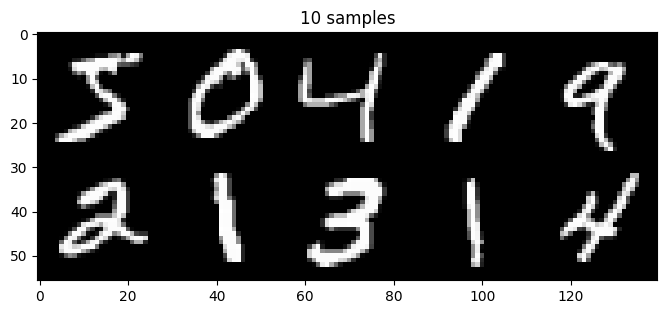

In [166]:
samples_10 = torch.stack([train_dataset[i][0] for i in range(10)])

mosaic = samples_to_mosaic_any_size(
    grid_size=(2, 5),
    samples=samples_10,
    image_shape=(28, 28)
)

plt.figure(figsize=(8, 4))
plt.imshow(mosaic, cmap='gray')
plt.title("10 samples")
plt.show()

**Question 1.2**: explicit how the images are expanded as vector by the pytorch functions:
 - What are the dimension of an image in the MNIST dataset? 
 - How are the matrix coordinates $(x,y)$ of a pixel converted into an index $z$ when they are transformed into a flat vector?

A MNIST image has the shape 28 x 28 pixels and can be flatten in a vector of the size 784.

The rows are stacked after each other, so the flatten index is: $28\cdot x + y$

## 2. Applying PCA to the MNIST dataset

In this part we will first analyse the MNIST dataset and try to reduce the number of dimensions using PCA. First we will try to understand what are the groups of pixels that contribute to the most variability in one digits, and see how this information can be used for compression of the images. We will also apply PCA to the whole set and set what it implies for continuous representations.

- To apply PCA, you can for instance use the `sklearn` module that was proposed in the last project, after converting the data vectors. 

- By default, you can consider the train cut of the dataset, even though in this part of the project, the train/test separation is not important. 



**Question 2.1**: Choose one of the digit in the MNIST dataset and fit a Principal Component Analysis on the samples for that digit (`3` is the digit used in the Bishop): 
- Represent the mean and the first 3 principal components' basis vectors for that image. As the PC can contain negative values, renormalize the values between 0 and 1 before plotting (0 values will be plotted as grey pixels). 
- Represent the proportion of the variance captured by the principal components as a function of the number of components (you can go up to 200 components).
- How many components are needed to be able to capture more that 80%, 90% or 95% of the variance? 

  


In [167]:
# Your code here. 

X, Y = [], []
for image, label in train_dataset:
    if label == 3:
        X.append(image.numpy())
        Y.append(label)

X = np.array(X)
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6131, 784), dtype=float32)

In [168]:
from sklearn.decomposition import PCA
pca = PCA(n_components=250)
pca.fit(X)

,n_components,250
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


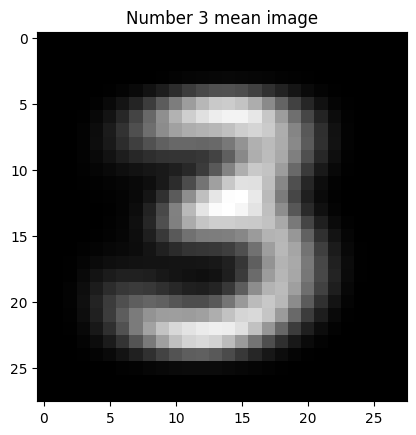

In [169]:
mean_image_3 = pca.mean_.reshape(28, 28)

plt.imshow(mean_image_3, cmap='gray')
plt.title("Number 3 mean image")
plt.show()

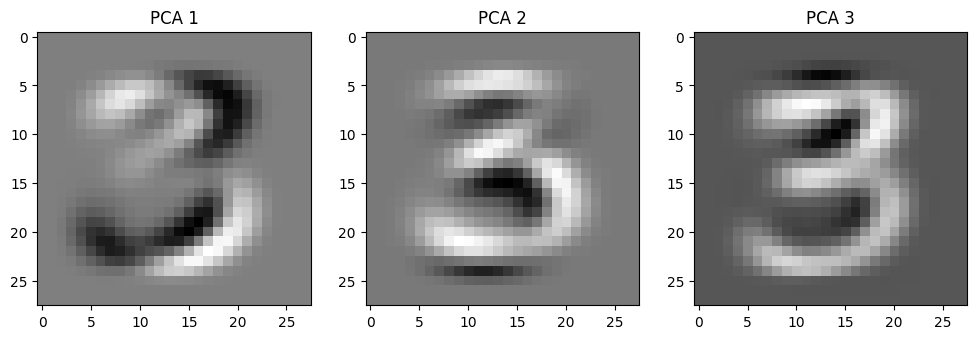

In [170]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i in range(3):
    image = pca.components_[i].reshape(28,28)

    image = image - image.min()
    image = image / image.max()

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"PCA {i+1}")

plt.show()

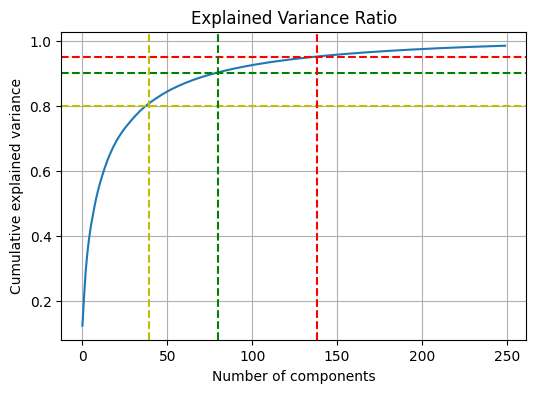

80% -> 39 components 
90% -> 80 components 
95% -> 138 components 


In [171]:
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)


thres08_n_components = np.argmax(explained_variance_ratio >= 0.8) + 1
thres09_n_components = np.argmax(explained_variance_ratio >= 0.9) + 1
thres095_n_components = np.argmax(explained_variance_ratio >= 0.95) + 1


plt.figure(figsize=(6,4))
plt.plot(explained_variance_ratio)
plt.xlabel("Number of components")
plt.axhline(y = 0.8, color='y', linestyle='--')
plt.axhline(y = 0.9, color='g', linestyle='--')
plt.axhline(y = 0.95, color='r', linestyle='--')
plt.axvline(x=thres08_n_components.astype(float),color='y', linestyle='--')
plt.axvline(x=thres09_n_components.astype(float),color='g', linestyle='--')
plt.axvline(x=thres095_n_components.astype(float),color='r', linestyle='--')
plt.ylabel("Cumulative explained variance")
plt.title("Explained Variance Ratio")
plt.grid()
plt.show()

print(f"80% -> {thres08_n_components} components ")
print(f"90% -> {thres09_n_components} components ")
print(f"95% -> {thres095_n_components} components ")



>39 components are necessary for a variance of minimum 80%, 80 for minimum of 90% and 138 for minimum of 95% variance.

**Question 2.2**: For the digit that was chosen, we will now take one sample and reconstruct it using $M=1, 10, 50$, and $250$ principal components. Let's have a look at the results:
- Plot the original and the reconstructed images, as show below for the digit `3` (taken from the chapter 12 of the Bishop book).
- What is the compression ratio achieved for each value of $M$?
- What is the Mean-Squared Error achieved (over all pixel) for each values of $M$? 



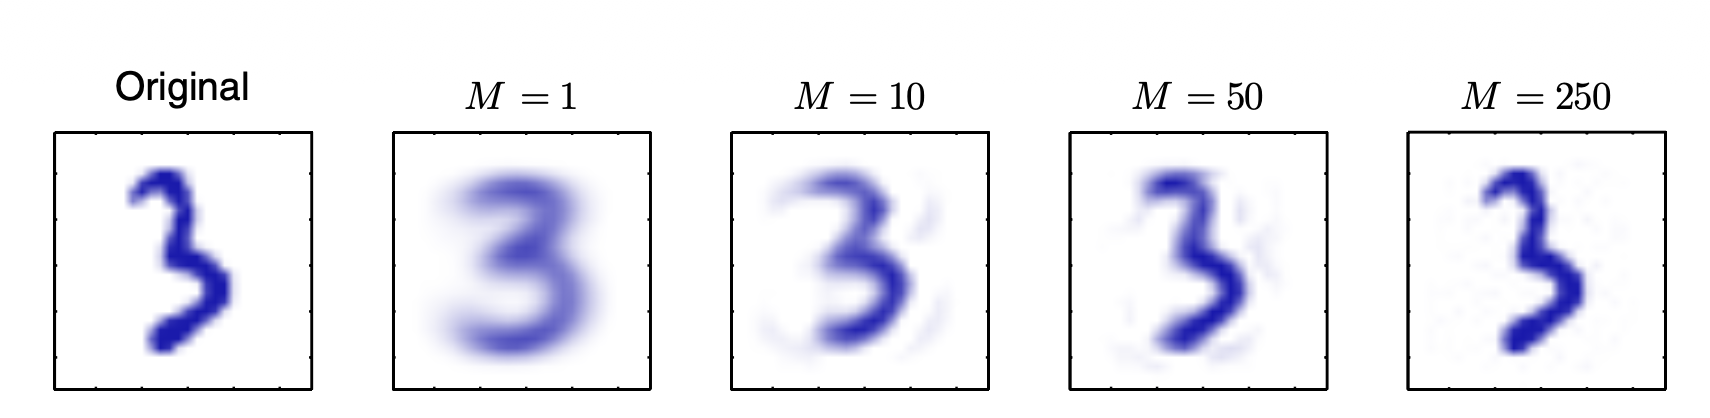

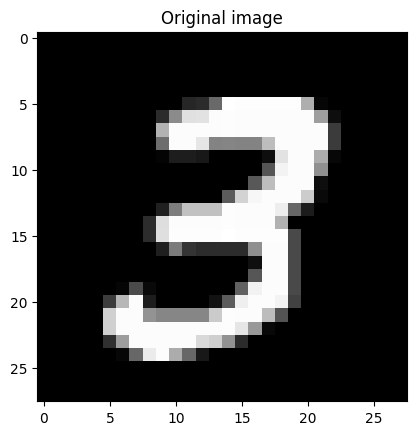

In [172]:
## Your code here 

sample = X[0]
sample_image = sample.reshape(28,28)

plt.imshow(sample_image, cmap='gray')
plt.title("Original image")
plt.show()


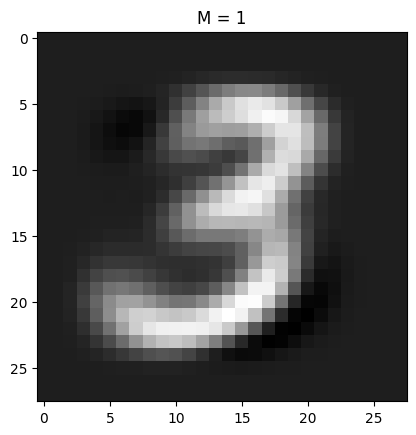

M = 1: ratio = 624.328
M = 1: MSE = 0.038055


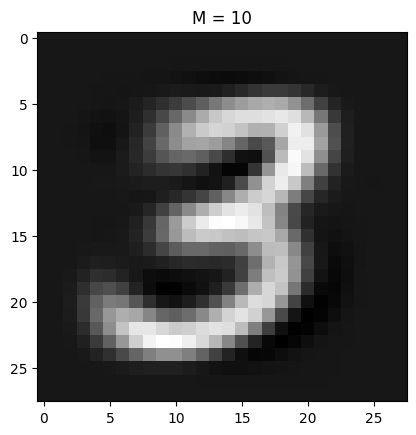

M = 10: ratio = 68.732
M = 10: MSE = 0.013065


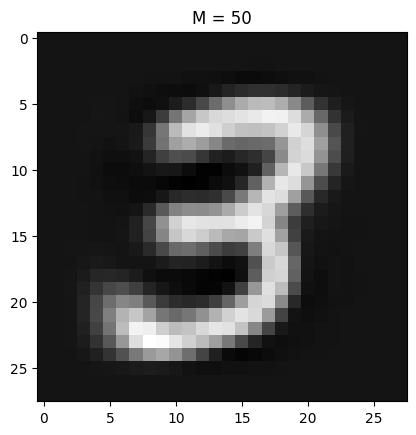

M = 50: ratio = 13.871
M = 50: MSE = 0.007511


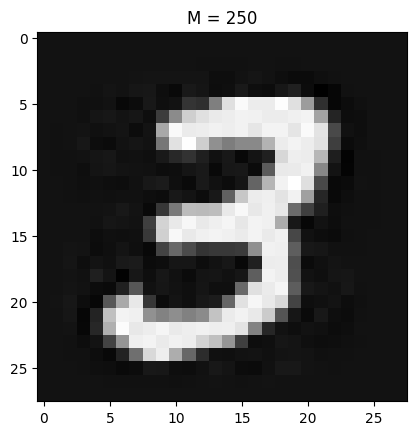

M = 250: ratio = 2.779
M = 250: MSE = 0.000597


In [173]:
from sklearn.metrics import mean_squared_error
m_values = [1, 10, 50, 250]

num_threes = len(X)

mses = []
ratios = []

for m in m_values:

    m_components = pca.components_[:m]
    mean = pca.mean_
    
    coe = np.dot(sample - mean, m_components.T)
    m_image = mean + np.dot(coe, m_components)    
    
    m_image = m_image.reshape(28,28)

    plt.imshow(m_image, cmap='gray')
    plt.title("M = " + str(m))
    plt.show()

    ratio = (num_threes*784) / (m_components.size + mean.size + num_threes*coe.size)
    ratios.append(ratio)
    print(f"M = {m}: ratio = {ratio:.3f}")
    mse = mean_squared_error(sample, m_image.flatten())
    mses.append(mse)
    print(f"M = {m}: MSE = {mse:.6f}")

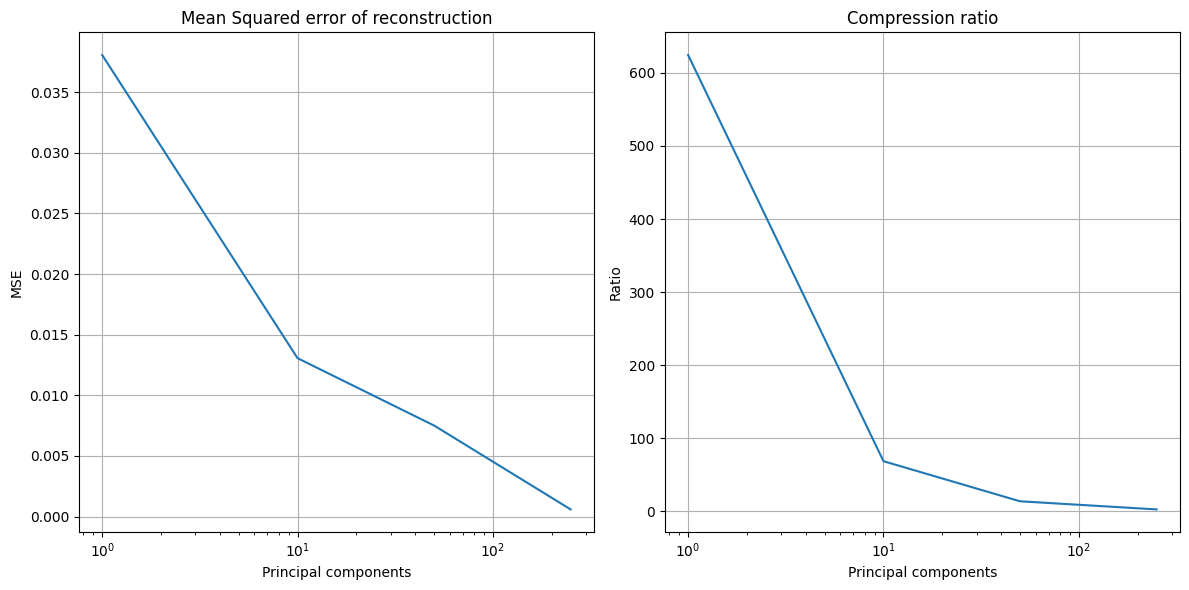

In [174]:
fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].plot(m_values, mses)
ax[0].set_title('Mean Squared error of reconstruction')
ax[0].set_xlabel('Principal components')
ax[0].set_ylabel('MSE')
ax[0].set_xscale('log')
ax[0].grid(visible=True)

ax[1].plot(m_values, ratios)
ax[1].set_title('Compression ratio')
ax[1].set_xlabel('Principal components')
ax[1].set_ylabel('Ratio')
ax[1].set_xscale('log')
ax[1].grid(visible=True)


plt.tight_layout()
plt.show()

We calculate the compression ratio with respect to the entire dataset. The size of the original is $784$ times the number of images, since each image has this amount of pixels. If we were to compress the dataset using the PCA, we have to save the principal components, the mean and the coefficients for each image. The ratio we display here is how much bigger the dataset is in comparison to the compressed version, so a factor $>1$ means that the compressed version is smaller than just saving the raw data.


**Question 2.3**: We will now apply PCA to the MNIST dataset with *all digits*. The idea is to see how the different digits are represented on the first principal components and how the dimensionality reduction still allows compression:
- Represent the samples on the first two principal components with a pairplot. You can take for instance `0`, `1`, and `2` and plot them in 3 different colors.
     1.  How are the digits occupying the plane? Do you notice some grouping?
     2.  Consider one digit and spread on the plane, how do they change as you move along?
- Represent the mean and the first 3 Principal Components, as in question 2.1.
- Redo the compression experiment for the sample you considered in Q2.2, how are the reconstruction and the MSE now?



In [175]:
## Your code here

X_all, Y_all = [], []

for image, label in train_dataset:
    X_all.append(image.numpy())
    Y_all.append(label)

X_all = np.array(X_all)
Y_all = np.array(Y_all)

pca_all = PCA(n_components=250)
X_pca = pca_all.fit_transform(X_all)

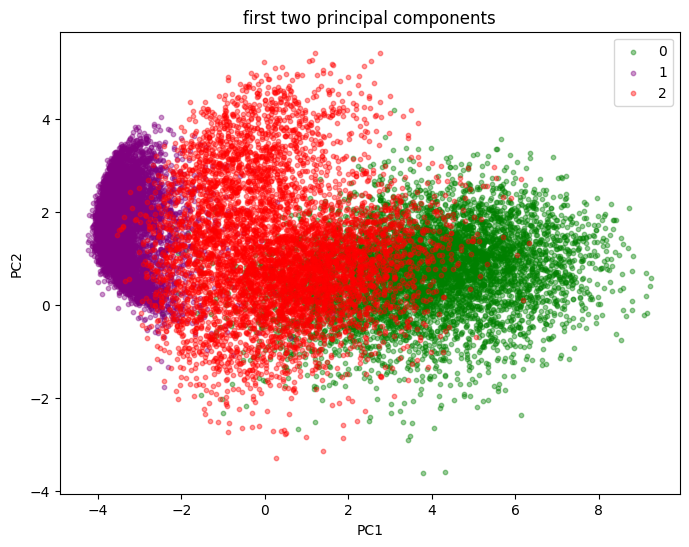

In [176]:
numbers = [0, 1, 2]
colors = ['green', 'purple', 'red']

plt.figure(figsize=(8,6))

for number, color in zip(numbers, colors):
    idx = Y_all == number
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=str(number), alpha=0.4, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("first two principal components")
plt.show()

In the pairplot is the grouping from the numbers (0 in green, 1 in purple and 2 in red) visible. You can see that they cluster a little bit, but for a good reconstruction of the image more principale components are needed.

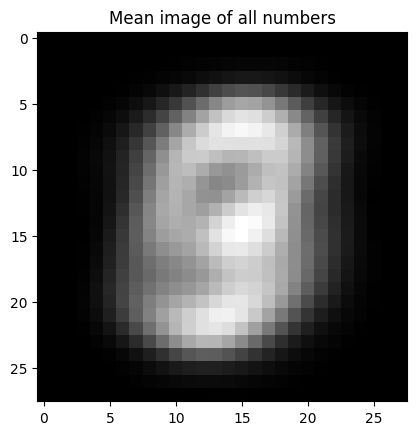

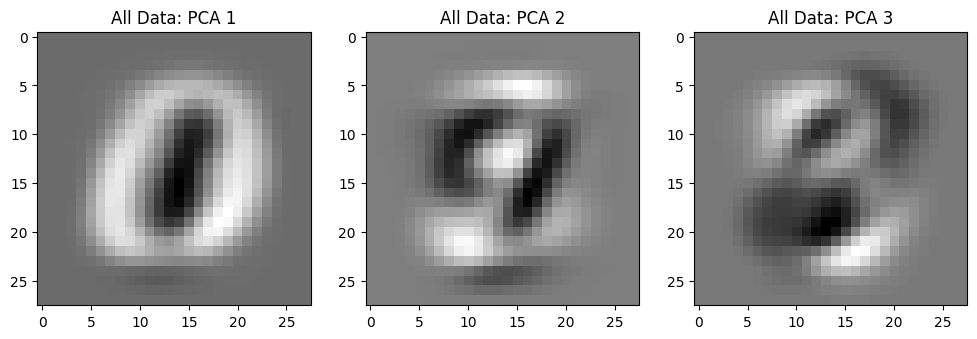

In [177]:
mean_image = pca_all.mean_.reshape(28,28)

plt.imshow(mean_image, cmap='gray')
plt.title("Mean image of all numbers")
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i in range(3):
    image = pca_all.components_[i].reshape(28,28)

    image = image - image.min()
    image = image / image.max()

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"All Data: PCA {i+1}")

plt.show()

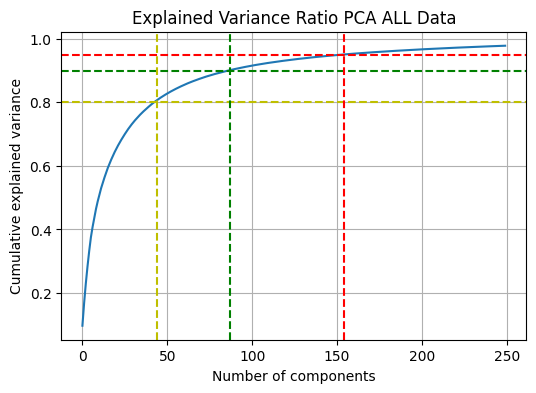

80% -> 44 components 
90% -> 87 components 
95% -> 154 components 


In [178]:
explained_variance_ratio = np.cumsum(pca_all.explained_variance_ratio_)

thres08_n_components = np.argmax(explained_variance_ratio >= 0.8) + 1
thres09_n_components = np.argmax(explained_variance_ratio >= 0.9) + 1
thres095_n_components = np.argmax(explained_variance_ratio >= 0.95) + 1

plt.figure(figsize=(6,4))
plt.plot(explained_variance_ratio)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained Variance Ratio PCA ALL Data")
plt.axhline(y = 0.8, color='y', linestyle='--')
plt.axhline(y = 0.9, color='g', linestyle='--')
plt.axhline(y = 0.95, color='r', linestyle='--')
plt.axvline(x =thres08_n_components.astype(float), color='y', linestyle='--')
plt.axvline(x = thres09_n_components.astype(float), color='g', linestyle='--')
plt.axvline(x = thres095_n_components.astype(float), color='r', linestyle='--')
plt.grid()
plt.show()



print(f"80% -> {thres08_n_components} components ")
print(f"90% -> {thres09_n_components} components ")
print(f"95% -> {thres095_n_components} components ")

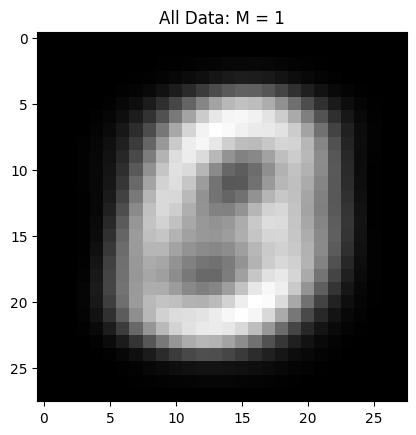

All Data: M = 1: ratio = 764.03
All Data: M = 1: MSE = 0.066586


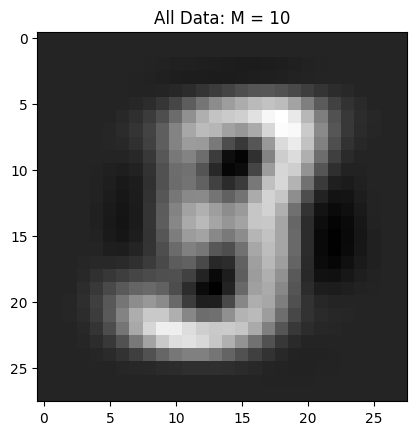

All Data: M = 10: ratio = 77.29
All Data: M = 10: MSE = 0.026611


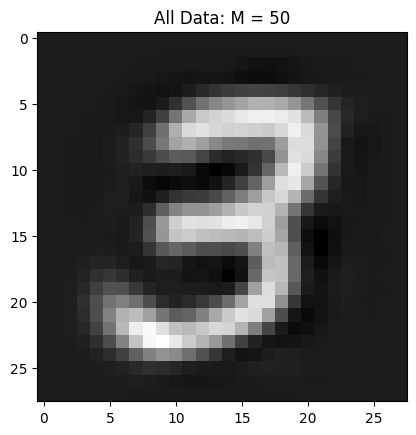

All Data: M = 50: ratio = 15.47
All Data: M = 50: MSE = 0.008363


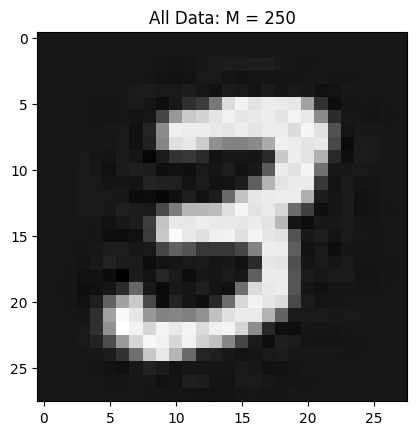

All Data: M = 250: ratio = 3.10
All Data: M = 250: MSE = 0.000915


In [179]:
from sklearn.metrics import mean_squared_error
m_values = [1, 10, 50, 250]

size_dataset = len(X_all)

ratios_all = []
mses_all = []

for m in m_values:

    m_components = pca_all.components_[:m]
    mean = pca_all.mean_
    
    coe = np.dot(sample - mean, m_components.T)
    m_image = mean + np.dot(coe, m_components)    
    
    m_image = m_image.reshape(28,28)

    plt.imshow(m_image, cmap='gray')
    plt.title("All Data: M = " + str(m))
    plt.show()

    ratio = (784*size_dataset) / (m_components.size + mean.size + size_dataset*coe.size)
    ratios_all.append(ratio)
    print(f"All Data: M = {m}: ratio = {ratio:.2f}")

    mse = mean_squared_error(sample, m_image.flatten())
    mses_all.append(mse)
    print(f"All Data: M = {m}: MSE = {mse:.6f}")

The first principal component has now a higher variance, the reason for that is that it not only captures the number 3, but all numbers. Beginning with M = 50 the number looks more like the number 3. We need 44 components for a variance of more than 80% and 154 components for a variance more than 95%

The MSE of the reconstructed image is slightly higher than before with the same number of components which is expected behaviour as now the same components have to capture more data than before and may therefore be less suited to a single digit. However the compression ratio is larger than before, so it is relatively better for the larger dataset.

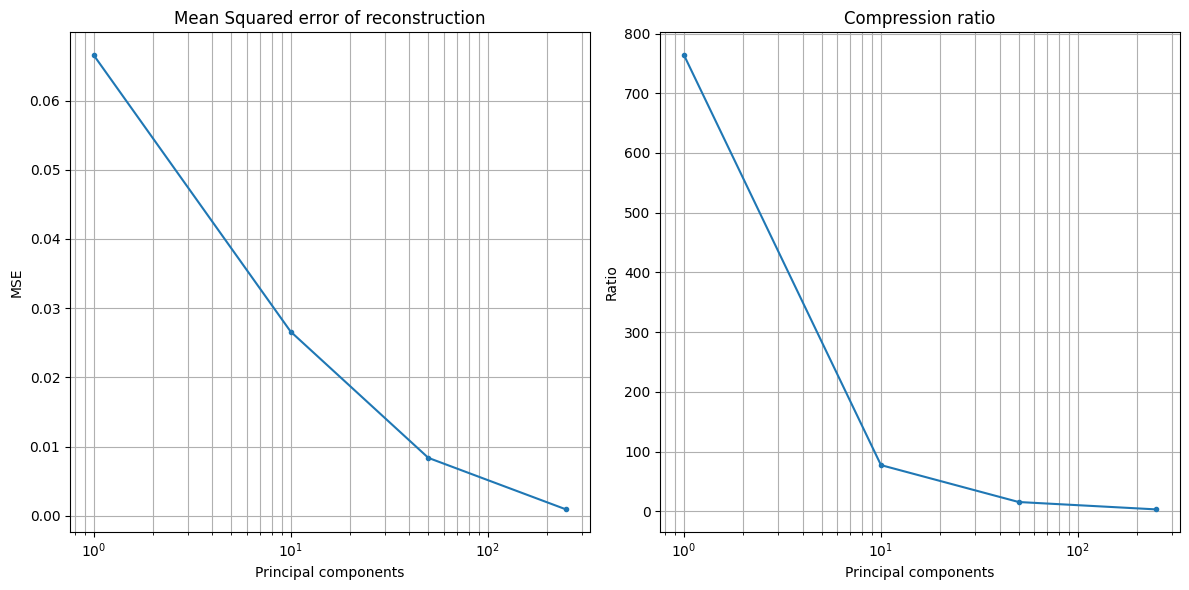

In [180]:
fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].plot(m_values, mses_all, marker='.')
ax[0].set_title('Mean Squared error of reconstruction')
ax[0].set_xlabel('Principal components')
ax[0].set_ylabel('MSE')
ax[0].set_xscale('log')
ax[0].grid(visible=True, which='both')

ax[1].plot(m_values, ratios_all, marker='.')
ax[1].set_title('Compression ratio')
ax[1].set_xlabel('Principal components')
ax[1].set_ylabel('Ratio')
ax[1].set_xscale('log')
ax[1].grid(visible=True, which='both')


plt.tight_layout()
plt.show()

## 3. Using MFA/MPPCA on the MNIST dataset

In this part we will train different mixture of factor analysis (MFA) models on the MNIST dataset and see how it performs. 
A mixture of factor analyser correspond to $K$ latent variables $\mathbf{z}_1, \ldots, \mathbf{z}_K$ which have each a number of factors $M$ (dimensionality reduction). 

We can write it as an extension of the previous pPCA and FA to mixtures:
$$
\mathbf{x} = \sum_{k=1}^{K} \pi_k\cdot W_k \mathbf{z}_k + \mu_k + \varepsilon_k
$$
Like for pPCA, $\mathbf{z_k} \sim \mathcal{N}(0, I_{M})$, and 
$\varepsilon_k \sim \mathcal{N}(0, \Psi_k)$


### Model training

The training of the model can be done by specifying its parameters with the `MFA` class, and then using the `batch_fit` torch primitive. 

The class `MFA` contains the following set of parameters (more details in `mfa.py`):
  - `n_features`: the number of features $D$
  - `n_components`: the parameter $K$
  - `n_factors`: the parameter $M$
  - `common_subspace`: a tensor of all the matrices $W_k$ of shape `[K, D, M]`.
  - `log_component_variances`: a tensor of the log variances $\log \Psi_k$ of shape `[K, D]`.
  - `PI_logits`: vector of the log-mixing coefficients: $(\log \pi_k)_{k=1,\ldots, K}$.

To create a new model with no fixed parameters, you just need to specify `n_features`, `n_components`, and `n_factors`. 
You can then use the torch primitive `batch_fit`. We recommend using the following parameters for training:
- maximum of 10 EM steps
- a batch size of 128 samples.

All default parameters are provided in the example code below. The manipulation of such models is more involved, so in this part of the project you are expected to manipulate helpers functions and provide comments and interpretations at each step of the analysis.

**Question 3.1**: Let's consider the basic properties of pPCA/FA and their mixture versions:
- Verify that the number of free parameters for a probabilistic PCA is $D(M+1) +1$ and $D(M+2)$ for a single factor analyzer
- What are the number of parameters for a mixture of factor analyzers?



For the pPCA, our free parameters are the projection matrix $W$, the mean $\mu$ and the isotropic variance parameter $\sigma$. $W$ projects from $\mathbb{R}^D$ ot $\mathbb{R}^M$, so it has dimension $D\times M$. $\mu$ is the mean in $\mathbb{R}^D$, so it has dimension $D$. Finally the noise parameter is just one number, so we have $DM + D + 1 = D(M+1) + 1$ free parameters.

For a single factor analyser the dimensionality of $W$ and $\mu$ remains unchanges, but now the noise is no longer isotropic. Instead of a single number, we now have a diagonal covariance matrix in $\mathbb{R}^{D \times D}$ and thus $D$ free parameters. In comparison to the pPCA model, we thus have $DM + D + D = D(M + 2)$ free parameters.

Since the mixture of factor analyzers consists of $K$ different factor analyzers, they have $KD(M+2)$ free parameters. We also have the "mixing" distribution $\pi$, which is a discrete distribution over $K$ singleton events and thus has $K - 1$ free parameters, as the distribution has to sum to one and the last entry is thereby determined when fixing the first $K - 1$. In total, such a model has $KD(M+2) + K - 1$ free parameters.

**Question 3.2**: Let's see how the MFA model can be trained on the MNIST dataset. We will fix $M$ the number of factors/PC to $2$, and vary $K$, the number of components.
- **a**. Train an MFA with $K=10$ components on the MNIST dataset (example code is provided below)
- **b**. For each component in the mixture, represent the mean and the first Principal Components. You can help yourself with the `visualize_model` helper function. What do you notice about the components? 
- **c**. Train other models with $K=20$ and $K=50$ components and compare the likelihoods. 
- **d**. Check how the reconstruction works for one digit with $K=10, 20, 50$ (you can use the same digit as the one you used in part 2). Report the MSE of the reconstructions as well. What the compression ratio in that case? 


In [181]:
image_shape = [28, 28]
figures_dir = Path('./figures/')
figures_dir.mkdir(exist_ok=True, parents=True)

In [182]:
##
## Parameters for running the mixture of components
##

def train_model(n_components, n_factors, n_iterations, i):
    ## This bolean switch allows to load an already trained model
    retrain = True
    ##
    image_shape = [28, 28]  # The input image shape
    n_components = n_components  # Number of components in the mixture model
    n_factors = n_factors  # Number of factors - the latent dimension (same for all components)
    batch_size = 128  # The EM batch size
    num_iterations = n_iterations

    ## Template model_name to save the results in a folder
    model_name = f'MNIST_{n_components}_l_{n_factors}_iter_{num_iterations}'

    ## preparing folder for saving the models and the figures
    device = torch.device('cpu')
    model_dir = Path('models/')
    model_dir.mkdir(parents=True, exist_ok=True)
    figures_dir = Path('./figures/') / model_name
    figures_dir.mkdir(exist_ok=True, parents=True)
    model_path = Path(model_dir / f'model_{model_name}.pth')

    ## Defining an MFA model, only needs K, D, and M.
    print('Defining the MFA model...')
    model = MFA(
        n_components=n_components,
        n_features=np.prod(image_shape),
        n_factors=n_factors,
    ).to(device=device)

    ## Model training, note the retrain boolean to allow reloading a model.
    ll_log = []
    if not retrain and model_path.exists():
        print('Loading existing model...', end='')
        load = torch.load(model_path, weights_only=True)
        model.load_state_dict(load)
        print('Done.')
    else:
        print(f'EM fitting: {n_components=} / {n_factors=} / {batch_size=} ...')

        ll_log = model.batch_fit(
            train_dataset,
            test_dataset,
            batch_size=batch_size,
            max_iterations=num_iterations,
        )

        print('Saving the model...', end='')
        torch.save(model.state_dict(), model_path)
        print('Done.')

    image_shape = (28, 28)
    print('Visualizing the trained model...')
    image_mode = 'L' if len(image_shape) == 2 else 'RGB'
    model_image = visualize_model(model, image_shape=image_shape, end_component=n_components)
    img = Image.fromarray(model_image, mode=image_mode)
    fig, ax = plt.subplots(1,1, figsize=(20, 10))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Model with {n_components} components")
    ax.axis('off')
    img.save(figures_dir / 'model_vis.png')

    return model, ll_log

/Users/hendrik/Documents/HPI-MA/S1/APML/pPCA_MNIST_project/mfa_helpers.py:309: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  *[MFA._small_sample_ppca(x[component_samples[i]], n_factors=l) for i in range(K)])]


Defining the MFA model...
EM fitting: n_components=10 / n_factors=2 / batch_size=128 ...
Random init with 6 samples per component...
Iteration 0/10, log-likelihood=-46.28335952758789:


E-step: processing batches: 100%|██████████| 469/469 [00:06<00:00, 76.11it/s] 

M-step: updating parameters

 (6.18 sec)
Iteration 1/10, log-likelihood=125.18640899658203:


E-step: processing batches: 100%|██████████| 469/469 [00:05<00:00, 88.21it/s] 

M-step: updating parameters

 (5.33 sec)
Iteration 2/10, log-likelihood=147.08287048339844:


E-step: processing batches: 100%|██████████| 469/469 [00:05<00:00, 86.62it/s] 

M-step: updating parameters

 (5.43 sec)
Iteration 3/10, log-likelihood=157.10440063476562:


E-step: processing batches: 100%|██████████| 469/469 [00:05<00:00, 92.57it/s] 

M-step: updating parameters

 (5.08 sec)
Iteration 4/10, log-likelihood=163.30181884765625:


E-step: processing batches: 100%|██████████| 469/469 [00:05<00:00, 86.02it/s] 

M-step: updating parameters

 (5.46 sec)
Iteration 5/10, log-likelihood=168.80223083496094:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 110.30it/s]

M-step: updating parameters

 (4.26 sec)
Iteration 6/10, log-likelihood=171.25096130371094:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 119.91it/s]

M-step: updating parameters

 (3.92 sec)
Iteration 7/10, log-likelihood=172.98936462402344:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 126.23it/s]

M-step: updating parameters

 (3.72 sec)
Iteration 8/10, log-likelihood=174.4316864013672:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 126.46it/s]

M-step: updating parameters

 (3.72 sec)
Iteration 9/10, log-likelihood=175.57630920410156:


E-step: processing batches: 100%|██████████| 469/469 [00:03<00:00, 127.08it/s]

M-step: updating parameters

 (3.70 sec)

Final train log-likelihood=176.85865783691406:
Saving the model...Done.
Visualizing the trained model...
Defining the MFA model...
EM fitting: n_components=20 / n_factors=2 / batch_size=128 ...
Random init with 6 samples per component...
Iteration 0/10, log-likelihood=9.69703483581543:


E-step: processing batches: 100%|██████████| 469/469 [00:05<00:00, 93.00it/s] 

M-step: updating parameters

 (5.06 sec)
Iteration 1/10, log-likelihood=174.21070861816406:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 98.49it/s] 

M-step: updating parameters

 (4.78 sec)
Iteration 2/10, log-likelihood=191.24290466308594:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 98.07it/s] 

M-step: updating parameters

 (4.80 sec)
Iteration 3/10, log-likelihood=198.98077392578125:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.69it/s] 

M-step: updating parameters

 (4.72 sec)
Iteration 4/10, log-likelihood=203.8123016357422:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.49it/s] 

M-step: updating parameters

 (4.73 sec)
Iteration 5/10, log-likelihood=208.78512573242188:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.59it/s] 

M-step: updating parameters

 (4.72 sec)
Iteration 6/10, log-likelihood=210.9302215576172:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.68it/s] 

M-step: updating parameters

 (4.72 sec)
Iteration 7/10, log-likelihood=213.43218994140625:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.76it/s] 

M-step: updating parameters

 (4.71 sec)
Iteration 8/10, log-likelihood=214.55722045898438:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.18it/s] 

M-step: updating parameters

 (4.74 sec)
Iteration 9/10, log-likelihood=215.3654022216797:


E-step: processing batches: 100%|██████████| 469/469 [00:04<00:00, 99.46it/s] 

M-step: updating parameters

 (4.73 sec)

Final train log-likelihood=217.7989044189453:
Saving the model...Done.
Visualizing the trained model...
Defining the MFA model...
EM fitting: n_components=50 / n_factors=2 / batch_size=128 ...
Random init with 6 samples per component...
Iteration 0/10, log-likelihood=87.35120391845703:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 59.65it/s]

M-step: updating parameters

 (7.89 sec)
Iteration 1/10, log-likelihood=222.24212646484375:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 59.89it/s]

M-step: updating parameters

 (7.87 sec)
Iteration 2/10, log-likelihood=247.46376037597656:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 59.53it/s]

M-step: updating parameters

 (7.92 sec)
Iteration 3/10, log-likelihood=256.9670104980469:


E-step: processing batches: 100%|██████████| 469/469 [00:08<00:00, 56.73it/s]

M-step: updating parameters

 (8.32 sec)
Iteration 4/10, log-likelihood=260.54071044921875:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 59.78it/s]

M-step: updating parameters

 (7.88 sec)
Iteration 5/10, log-likelihood=263.99261474609375:


E-step: processing batches: 100%|██████████| 469/469 [00:08<00:00, 56.27it/s]

M-step: updating parameters

 (8.37 sec)
Iteration 6/10, log-likelihood=265.4940490722656:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 59.65it/s]

M-step: updating parameters

 (7.90 sec)
Iteration 7/10, log-likelihood=267.1745300292969:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 60.43it/s]

M-step: updating parameters

 (7.80 sec)
Iteration 8/10, log-likelihood=270.4143981933594:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 60.95it/s]

M-step: updating parameters

 (7.73 sec)
Iteration 9/10, log-likelihood=271.3573303222656:


E-step: processing batches: 100%|██████████| 469/469 [00:07<00:00, 60.40it/s]

M-step: updating parameters (7.80 sec)

Final train log-likelihood=271.9944152832031:
Saving the model...Done.
Visualizing the trained model...


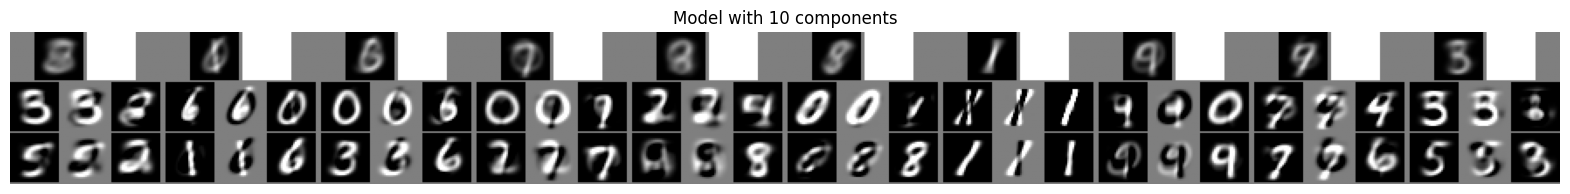

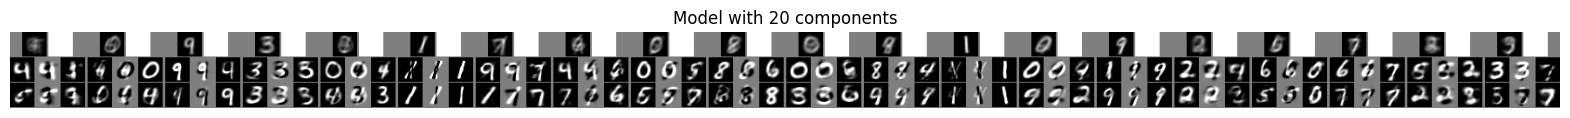

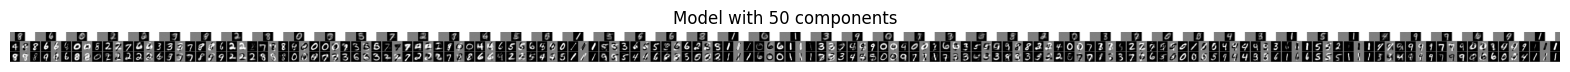

In [183]:
## Your code here
model10, ll10 = train_model(10, 2, 10, 0)
model20, ll20 = train_model(20, 2, 10, 1)
model50, ll50 = train_model(50, 2, 10, 2)

For the initial model with 10 components, we see some components whose mean seems to clearly represent a digit, like the fourth component, which has a three as its mean image. But we can also see that the different dimensions of the latent space may also capture other digits. Within the same component, the mean of only the first dimension looks like a two. Other components have quite garbled up means that do not look like anything really. With a higher number of components, we see more digits represented in the means of the subspaces and there are also some duplicates since there are only 10 digits that could be captured by a factor.

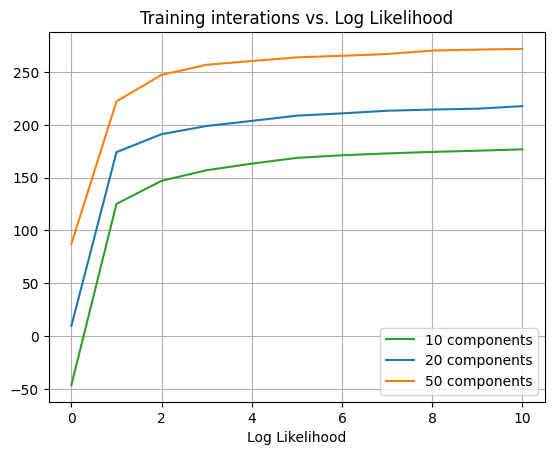

In [184]:
plt.plot(ll10, label="10 components", color='tab:green')
plt.plot(ll20, label="20 components", color='tab:blue')
plt.plot(ll50, label="50 components", color='tab:orange')
plt.legend()
plt.title('Training interations vs. Log Likelihood')
plt.xlabel('Training iterations')
plt.xlabel('Log Likelihood')
plt.grid(visible=True, which='both')
plt.show()


We can immediately notice that the likelihood of the model improves with an increased number of components, and that this also leads to a higher initial likelihood of the model.

In [185]:
# For question 3.2.b
# Visualizes the components of the trained MFA model. 
# The header shows the mean and the std. dev. of each component. 
# The rows below show the factors: mean, direction/factor loadings, and
# mean - direction/factor loadings.

In [186]:
def mfa_model_size(model):
    subspace_size = np.prod(model.common_subspace.shape)
    mean_size = np.prod(model.means.shape)
    var_size = np.prod(model.log_component_variances.shape)
    distribution_size = np.prod(model.PI_logits.shape)

    return subspace_size + mean_size + var_size + distribution_size

In [187]:
def pca_model_size(PCA, n_components):
    m_components = PCA.components_[:n_components]
    mean = PCA.mean_
    return m_components.size + mean.size

M = 10: MSE = 0.046968
M = 10: ratio = 310.762


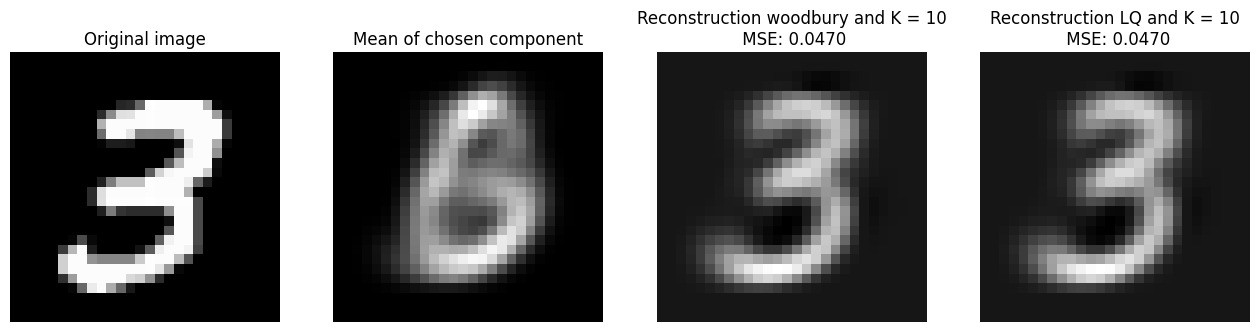

M = 20: MSE = 0.034995
M = 20: ratio = 257.415


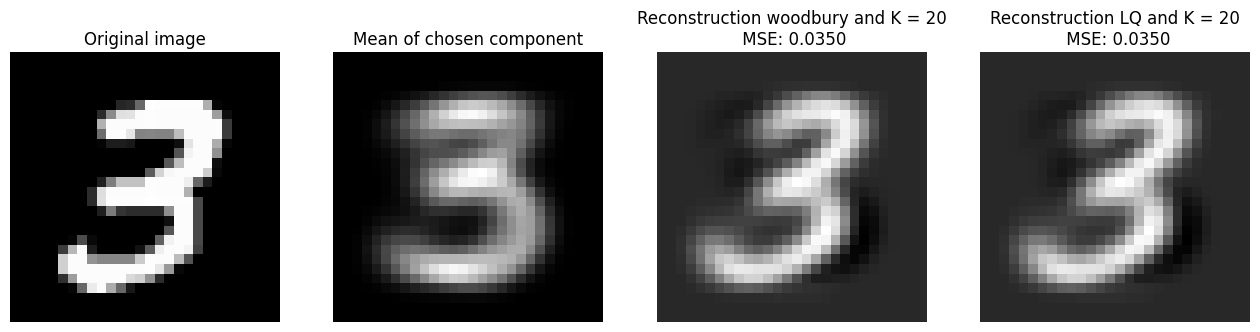

M = 50: MSE = 0.020614
M = 50: ratio = 169.912


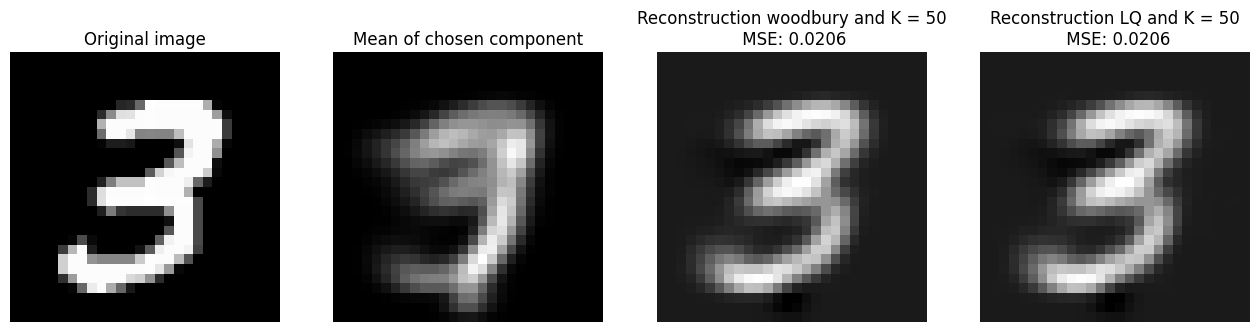

In [188]:
models = [model10, model20, model50]

size_dataset = len(X_all)

mses_mfa = []
ratios_mfa = []

for model in models:

    torch_sample = torch.tensor(sample)
    most_likely_component = model.map_component(torch_sample)
    
    # lifted from the conditional reconstruct
    inverse_variance = torch.exp(-model.log_component_variances[most_likely_component]).unsqueeze(2)
    deviation = (torch_sample - model.means[most_likely_component]).unsqueeze(2)
    projection_matrix = model.common_subspace[most_likely_component]

    latent_projection = ((projection_matrix * inverse_variance).transpose(1, 2) @ deviation)

    # mal schauen
    identity_matrix = torch.eye(model.n_factors, device=torch_sample.device).reshape(1, model.n_factors, model.n_factors)
    L = identity_matrix + projection_matrix.transpose(1, 2) @ (inverse_variance * projection_matrix)
    inverse_L = torch.inverse(L)

    woodbury_correction = projection_matrix.transpose(1, 2) @ (
            inverse_variance * (projection_matrix @ inverse_L @ latent_projection)
        )

    m_image = model.means[most_likely_component].unsqueeze(2) \
              +  (projection_matrix @ latent_projection) \
              - (projection_matrix @ woodbury_correction) 
    
    m_image = m_image.reshape(28,28)

    mse = mean_squared_error(sample, m_image.flatten())
    mses_mfa.append(mse)
    print(f"M = {model.n_components}: MSE = {mse:.6f}")

    ratio = (size_dataset*784) / (mfa_model_size(model) + size_dataset*np.prod(latent_projection.shape))
    ratios_mfa.append(ratio)
    print(f"M = {model.n_components}: ratio = {ratio:.3f}")

    fig, ax = plt.subplots(1,4, figsize=(16,6))
    ax[0].imshow(sample.reshape(28,28), cmap='gray')
    ax[0].set_title("Original image")
    ax[0].axis('off')

    ax[1].imshow(model.means[most_likely_component].reshape(28,28), cmap='gray')
    ax[1].set_title("Mean of chosen component")
    ax[1].axis('off')

    ax[2].imshow(m_image, cmap='gray')
    ax[2].set_title(f"Reconstruction woodbury and K = {model.n_components}\n MSE: {mse:.4f}")
    ax[2].axis('off')

    wTw = projection_matrix.transpose(1,2) @ projection_matrix
    wTw_inverse = torch.inverse(wTw)

    latent_projection = wTw_inverse @ projection_matrix.transpose(1,2) @ deviation
    new_image = model.means[most_likely_component].unsqueeze(2) + projection_matrix @ latent_projection

    mse_lq = mean_squared_error(sample, new_image.flatten())
    ax[3].imshow(new_image.reshape(28, 28), cmap='gray')
    ax[3].set_title(f"Reconstruction LQ and K = {model.n_components}\n MSE: {mse_lq:.4f}")
    ax[3].axis('off')

    plt.show()
    

We first choose a component where the sample image is most likely to originate from. We use this approach instead of mixing according to the responsibilities, since a) the code for the reconstruction does it like this as well and we hope they made an informed decision and b) during testing, the responsibilites were always almost exactly one for one component and 0 for the others, so the leads to the same result. After this we have to project the sample into the latent space of this component. The first time, we lift the projection equations from the conditional reconstruct function, provided with the model. This uses the Woodbury identity to avoid some more expensive inverses. We then also use the Least Squares projection trick to find the respective projection, as also used with Linear Regression. We find that, at least visually, these two methods do not seem to deviate much. 

For the compression we calculate the size of the model with the size of the subspace matrices, the means, the variances and the mixing distribution. Although we could argue that the variances are not really required, since the least sqaures projection omits them from the calculation and seems to achieve similar results.

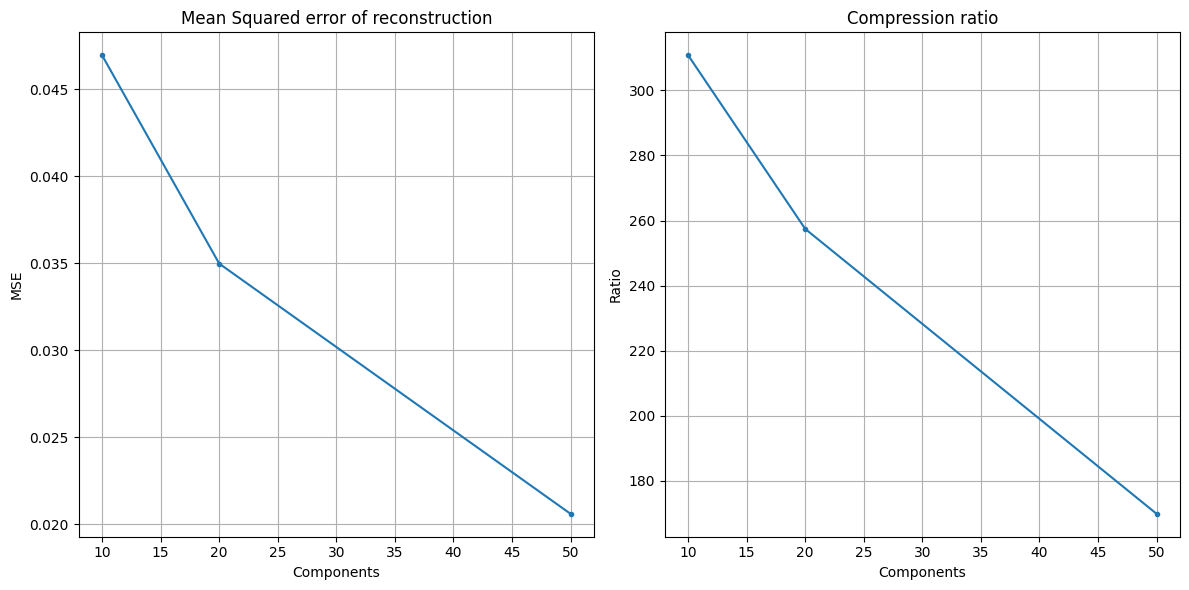

In [189]:
component_values = [model.n_components for model in models]

fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].plot(component_values, mses_mfa, marker='.')
ax[0].set_title('Mean Squared error of reconstruction')
ax[0].set_xlabel('Components')
ax[0].set_ylabel('MSE')
# ax[0].set_xscale('log')
ax[0].grid(visible=True, which='both')

ax[1].plot(component_values, ratios_mfa, marker='.')
ax[1].set_title('Compression ratio')
ax[1].set_xlabel('Components')
ax[1].set_ylabel('Ratio')
# ax[1].set_xscale('log')
ax[1].grid(visible=True, which='both')


plt.tight_layout()
plt.show()

In [190]:
model_size_mfa = [mfa_model_size(model) for model in models]
model_size_pca = [pca_model_size(pca_all, m) for m in m_values]

print(model_size_mfa)
print(model_size_pca)

[np.int64(31370), np.int64(62740), np.int64(156850)]
[1568, 8624, 39984, 196784]


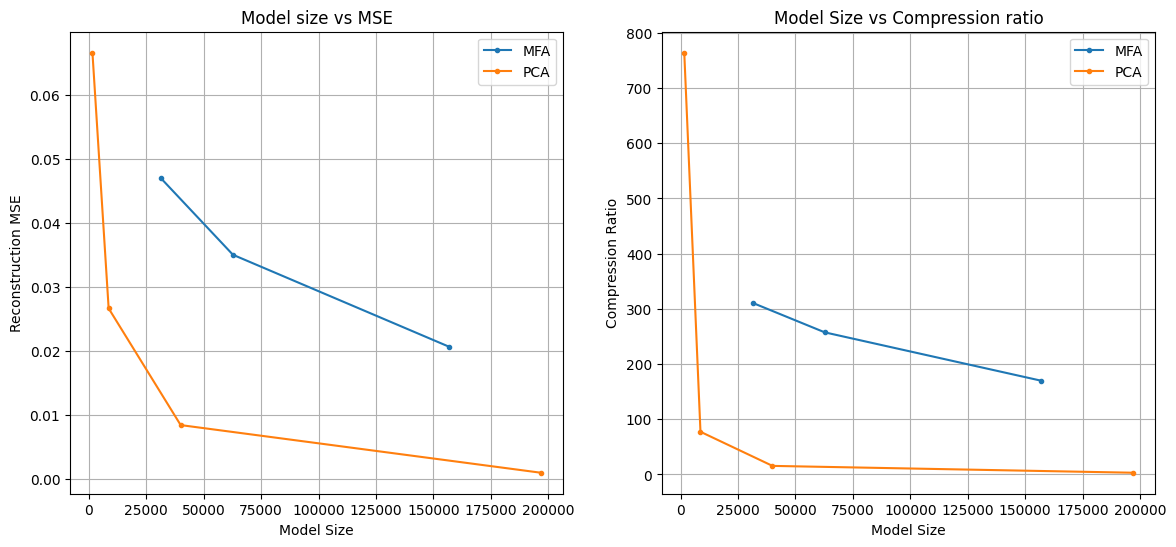

In [191]:
fig, ax = plt.subplots(1,2, figsize=(14,6))
ax[0].plot(model_size_mfa, mses_mfa, label="MFA", marker='.')
ax[0].plot(model_size_pca, mses_all, label="PCA", marker='.')
ax[0].legend()
ax[0].set_xlabel('Model Size')
ax[0].set_ylabel('Reconstruction MSE')
ax[0].set_title('Model size vs MSE')
ax[0].grid(visible=True, which='both')

ax[1].plot(model_size_mfa, ratios_mfa, label="MFA", marker='.')
ax[1].plot(model_size_pca, ratios_all, label="PCA", marker='.')
ax[1].legend()
ax[1].set_xlabel('Model Size')
ax[1].set_ylabel('Compression Ratio')
ax[1].set_title('Model Size vs Compression ratio')
ax[1].grid(visible=True, which='both')

plt.show()

We see, that MFA models with our specified number of factors (2) have a higher MSE when decompressing a specific image from the dataset than PCA models of similar size (similar number of parameters) but also achieve much higher compression ratios when considering the whole dataset.

### Simulating samples 


**Question 3.3**: We want to see how it works with simulation. On the model with $K=10$ and the one with $K=50$ components, simulate a hundred samples and plot them. Compare the properties of the samples for the different number of components.

Below an example code to generate samples and plot them.

In [192]:
def random_sample(model, figure_path, n_samples=100):
    print('Generating random samples...')
    rnd_samples, _ = model.sample(n_samples)
    mosaic = samples_to_mosaic(rnd_samples, image_shape=image_shape)
    img = Image.fromarray(mosaic)
    img.save(figures_dir / figure_path / 'samples.png')
    return mosaic

Generating random samples...
Generating random samples...


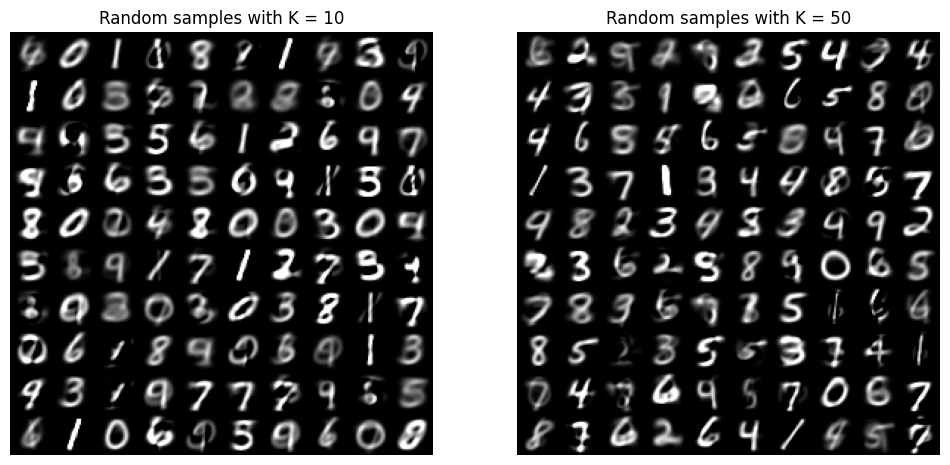

In [193]:
mosaic10 = random_sample(model10, "MNIST_10_l_2_iter_10")
mosaic50 = random_sample(model50, "MNIST_50_l_2_iter_10")

fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].imshow(mosaic10, cmap='gray')
ax[0].set_title(f"Random samples with K = 10")
ax[0].axis('off')
ax[1].imshow(mosaic50, cmap='gray')
ax[1].set_title(f"Random samples with K = 50")
ax[1].axis('off')
plt.show()

There are some clearly distiguishable and defined numbers among the randomly generated samples. Since the random vectors of the latent spaces are sampled according to $\mathcal{N}(0,1)$, they usually lie within the more clearly defined regions of the embedding spaces (as we will see in the following task). However there are also garbled up "digits" present in both random samples.

### Visualizing the embeddings. 

**Question 3.4**: Having an embedding in the latent space enables to maps the point in the training samples to a continuous representation. The code below is a way to represent the latent space of each component on a grid. Please describe what the code below is doing and provide a short comparison between the grids for $K=10$ and $K=50$ components. 

In [194]:
## Visualizing latent space by generating samples from a grid in the latent space

## Function for generating the samples
def generate_sample_from_latents(model, latents, component=None):
    if torch.all(model.common_subspace == 0.0):
        warnings.warn("SGD MFA training requires initialization. Please call batch_fit() first.")
    # assert latents.shape[1] == model.n_factors
    n = latents.shape[0]

    if component is None:
        c_nums = np.random.choice(
            model.n_components,
            n,
            p=torch.softmax(model.PI_logits, dim=0).detach().cpu().numpy(),
        )
    else:
        c_nums = torch.full((latents.shape[0], ), component, dtype=torch.int)
        padded_latents = torch.zeros((latents.shape[0], model.n_factors), device=latents.device)
        padded_latents[:, :latents.shape[1]] = latents

    z_d = torch.zeros(n, model.n_features, device=model.common_subspace.device)

    samples = torch.stack(
        [
            model.common_subspace[c_nums[i]] @ padded_latents[i]
            + model.means[c_nums[i]]
            + z_d[i] * torch.exp(0.5 * model.log_component_variances[c_nums[i]])
            for i in range(n)
        ]
    )

    return samples, c_nums

def grid_to_image(grid_coords, samples, image_shape=(64, 64, 3)):
    images = samples_to_np_images(samples, image_shape)
    num_cols = int(np.sqrt(grid_coords.shape[0]))
    num_rows = int(np.sqrt(grid_coords.shape[0]))
    assert num_cols * num_rows == grid_coords.shape[0], "grid_coords shape is not a perfect square"
    if len(image_shape) == 2:
        new_image = torch.zeros((num_rows * image_shape[0], num_cols * image_shape[1]), dtype=torch.float32)
        for i in range(num_rows):
            for j in range(num_cols):
                new_image[
                    i * image_shape[0]:(i + 1) * image_shape[0],
                    j * image_shape[1]:(j + 1) * image_shape[1],
                ] = torch.from_numpy(images[i * num_cols + j])
    elif len(image_shape) == 3:
        new_image = torch.zeros((num_rows * image_shape[0], num_cols * image_shape[1], image_shape[2]), dtype=torch.float32)
        for i in range(num_rows):
            for j in range(num_cols):
                new_image[
                    i * image_shape[0]:(i + 1) * image_shape[0],
                    j * image_shape[1]:(j + 1) * image_shape[1],
                    :,
                ] = torch.from_numpy(images[i * num_cols + j])
    else:
        raise ValueError("image_shape must be of length 2")

    return (new_image.numpy() * 255).astype(np.uint8)

In [195]:
from math import sqrt, floor, ceil

## Represent all the samples on a grid, plotting commands
def vis_latent_space(model, n_components):
    grid_size = 20
    latent_grid = torch.linspace(-3, 3, steps=grid_size)
    grid_coords = torch.cartesian_prod(latent_grid, latent_grid)  # (100,

    print(grid_coords.shape)
    print(model.n_factors)

    grid_size = [ceil(n_components / 4), 4]
    fig, ax = plt.subplots(grid_size[0], grid_size[1], figsize=(12, grid_size[0]*4))

    for component_idx in range(model.n_components):
        samples, c_nums = generate_sample_from_latents(model, grid_coords, component=component_idx)

        # display samples as grid
        mosaic = grid_to_image(grid_coords, samples, image_shape=image_shape)
        img = Image.fromarray(mosaic)
        axes_idx = component_idx // grid_size[1], component_idx % grid_size[1]
        ax[axes_idx].imshow(mosaic, cmap="gray")
        ax[axes_idx].axis('off')
        ax[axes_idx].set_title(f"Component {component_idx}")
        img.save(figures_dir / f"MNIST_{n_components}_l_2_iter_10" /f'component_{component_idx}_latent_grid.png')
    for idx in range(model.n_components, grid_size[0] * grid_size[1]):
        axes_idx = idx // grid_size[1], idx % grid_size[1]
        ax[axes_idx].axis('off')

    plt.tight_layout()
    plt.show()

torch.Size([400, 2])
2


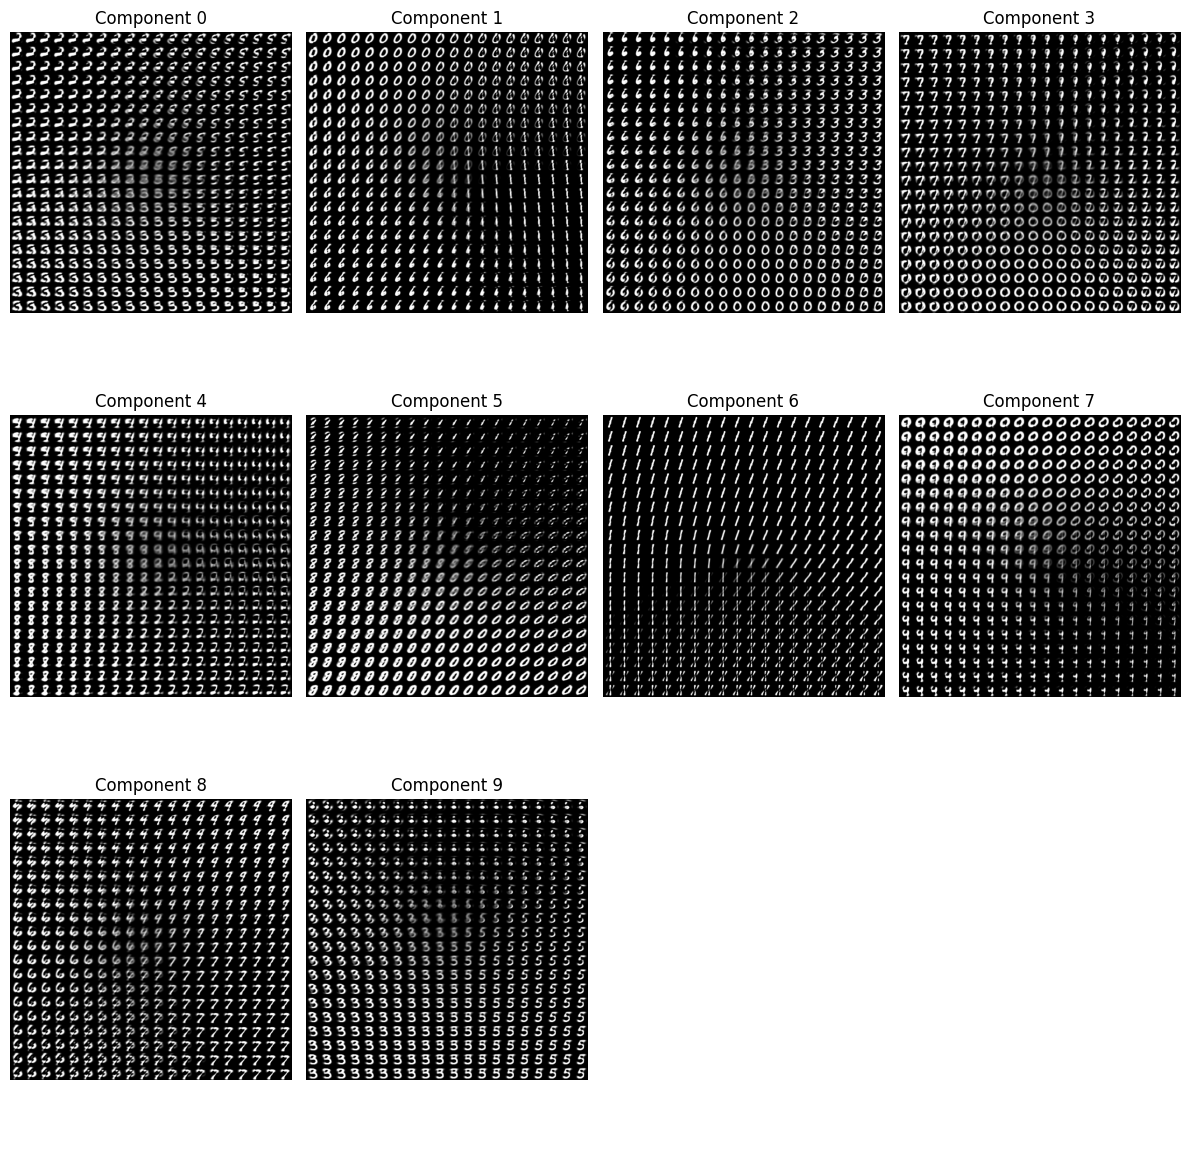

torch.Size([400, 2])
2


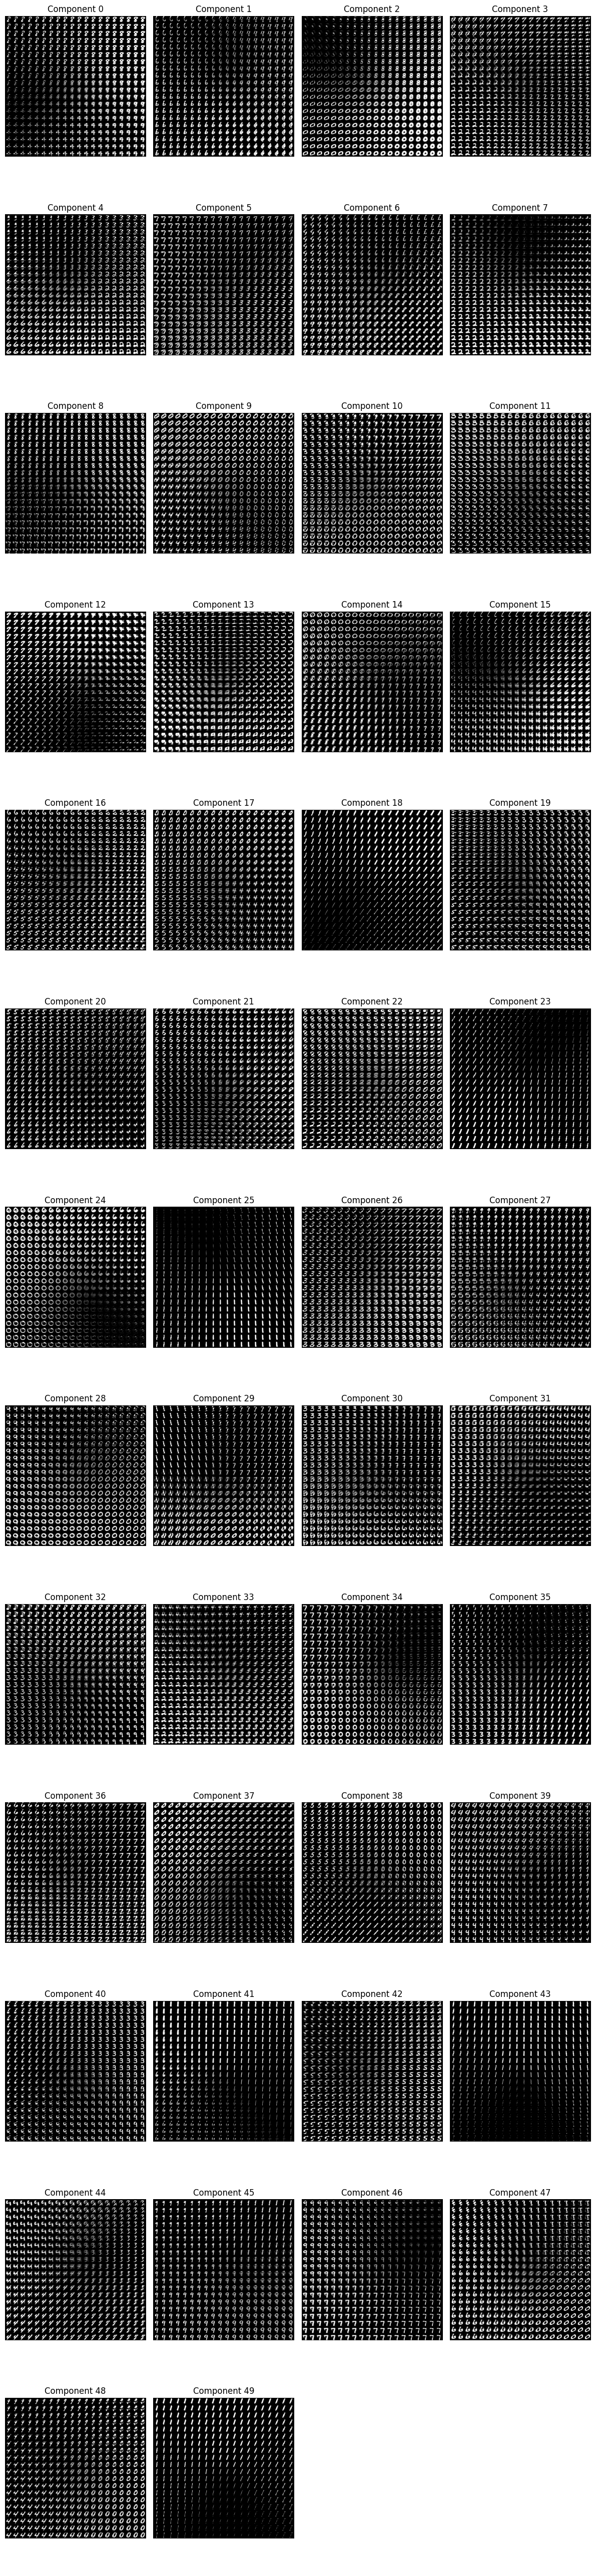

In [196]:
vis_latent_space(model10, 10)
vis_latent_space(model50, 50)

We want to look at the latent space represented by each component. For this, we look at a few latent vectors and calculate the image they represent. For this, the code generates $20$ evenly spaced numbers from $-3$ to $3$ and takes their cartesian product, so we get an evently spaced $20 \times 20$ grid centered at the origin. These are the latent vectors we use to visualize the latent space. The code then pads these latent vectors (maybe to make the code more robust, in case there are less dimensions specified than the latent space has). After this, the latent vectors are multiplied by the projection matrix and the corresponding mean of the component is added. There is also something happening with the learned variance, but everything there gets multiplied by a zero vector, as initialized by ```torch.zeros(...)```, so this doesn't contribute anything. 

### Reconstructing original masked images, impainting

**Question 3.4** We are exploring how the mixture of factors can provide impainting. The code below provides a way to mask images on part of it and perform impainting. 
- Describe what the code is doing to perform impainting. What are the quantities computed? 
- Compare the quality of the impainting for $K=10$ and $K=50$ on your selection of of the masking. 


In [197]:
## 5 masking strategies are proposed: "center", "bottom", "top", "right", "left"
def impaint(model, mask_type, K):

    print('Reconstructing images from the trained model...', end='')
    grid_size = [5, 5]
    n = grid_size[0] * grid_size[1]
    random_samples, _ = zip(
        *[test_dataset[k] for k in RandomSampler(test_dataset, replacement=True, num_samples=n, generator=torch.Generator())]
    )  #num_samples -> grid_size = [m1, m2]
    random_samples = torch.stack(random_samples)

    # w = image_shape[0]
    # mask = np.ones([3, w, w], dtype=np.float32)  # Hide part of each image

    # torch dimensions are generally in (C, H, W) format
    shape_reversed = image_shape[::-1]
    if len(shape_reversed) == 2:
        shape_reversed = [1] + shape_reversed  # Add channel dimension for grayscale images
    height = shape_reversed[1]
    width = shape_reversed[2]
    mask = np.ones(shape_reversed, dtype=np.float32)  # Hide part of each image

    if mask_type == "center":
        mask[:, height // 4:-height // 4, width // 4:-width // 4] = 0  #Masking centre
        mask_suffix = 'center'
    elif mask_type == "bottom":
        mask[:, height // 2:, :] = 0  #Masking bottom half
        mask_suffix = 'bottom'
    elif mask_type == "right":
        mask[:, :, width // 2:] = 0  #Masking right half
        mask_suffix = 'right'
    elif mask_type == "left":
        mask[:, :, : width // 2] = 0  #Masking left half
        mask_suffix = 'left'
    elif mask_type == "top":
        mask[:, :height // 2, :] = 0  #Masking top half
        mask_suffix = 'top'
    else:
        mask[:, height // 2 + height // 10:, :] = 0
        mask_suffix = 'lessBottom'

    mask = torch.from_numpy(mask.flatten()).reshape([1, -1])
    fig, ax = plt.subplots(1,3, figsize=(12, 6))

    mosaic_original_unmasked = samples_to_mosaic_any_size(grid_size, random_samples, image_shape=image_shape)
    ax[0].imshow(mosaic_original_unmasked, cmap="grey")
    ax[0].axis('off')
    ax[0].set_title("Original images")

    random_samples *= mask
    used_features = torch.nonzero(mask.flatten()).flatten()
    reconstructed_samples = model.conditional_reconstruct(
        random_samples.to(model.common_subspace.device),
        observed_features=used_features
    ).cpu()
    reconstructed_samples = random_samples * mask + reconstructed_samples * (1 - mask)

    fig_path = f"MNIST_{K}_l_2_iter_10"
    mosaic_original = samples_to_mosaic_any_size(grid_size, random_samples, image_shape=image_shape)
    fname = figures_dir / fig_path /f'original_samples_{mask_suffix}_masked.png'
    ax[1].axis('off')
    ax[1].imshow(mosaic_original, cmap='gray')
    ax[1].set_title("Original images with " + mask_suffix + " masked")

    Image.fromarray(mosaic_original).save(fname)

    mosaic_reconstructed = samples_to_mosaic_any_size(grid_size, reconstructed_samples, image_shape=image_shape)
    fname = figures_dir / fig_path / f'reconstructed_samples_{mask_suffix}_masked.png'
    ax[2].axis('off')
    ax[2].imshow(mosaic_reconstructed, 'gray')
    ax[2].set_title(f"Reconstructed images with K = {K}")

    plt.tight_layout()
    plt.show()
    Image.fromarray(mosaic_reconstructed).save(fname)
    print('Done.')

Reconstructing images from the trained model...

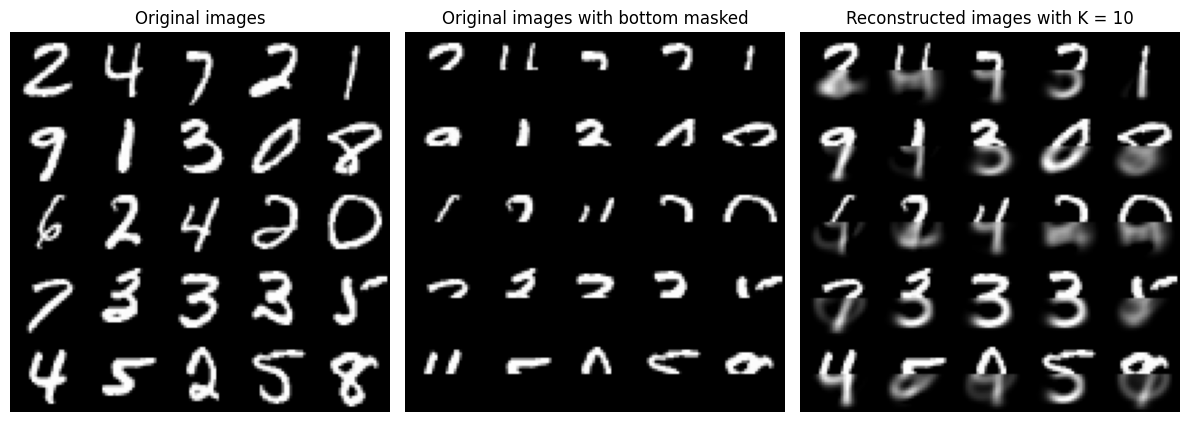

Done.
Reconstructing images from the trained model...

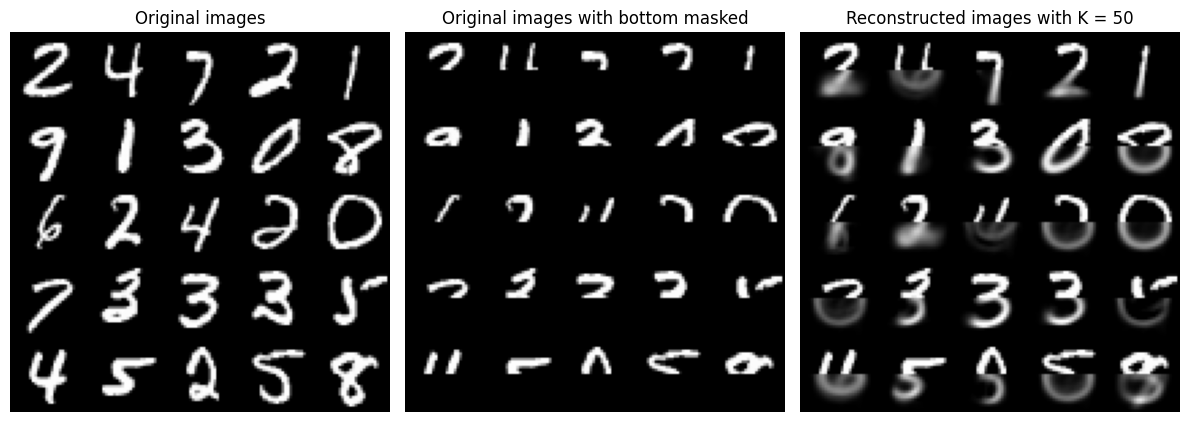

Done.


In [198]:
impaint(model10, "bottom" , 10)
impaint(model50, "bottom" , 50)

Reconstructing images from the trained model...

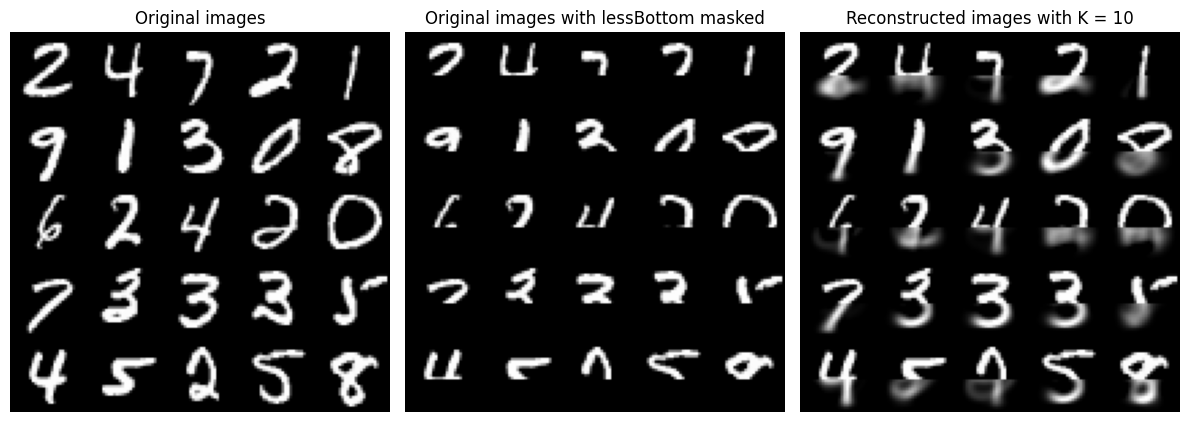

Done.
Reconstructing images from the trained model...

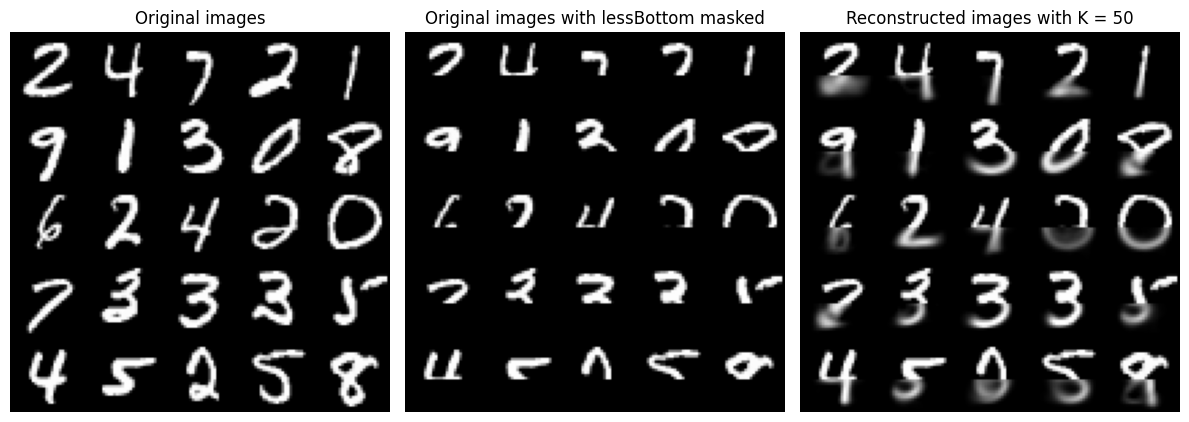

Done.


In [199]:
impaint(model10, "" , 10)
impaint(model50, "" , 50)

Depending on the mask type, different parts of the sampled image are masked by multiplying all corresponding pixel values by $0$. For the reconstruction, the model calculates the a-posteriori probabilities for each component and the masked image and then uses the one with the highest one. For this, it uses the Mahalanobis distance of the sample to the projected latent representation of the sample, incorporating the variance of the model. It the removes the masked features from the means and covariance matrices of the components and projects the observed sample into the latent space. It then computes $\mathbb{E}\left[x_\text{hidden} ~|~ x_\text{observed}\right]$ to impute the value of the masked pixels.

The model with 50 components seems to want to turn everything into a zero, at least with this bottom masking. The model with 10 components does not exhibit this behaviour with these specific digits, but here we have the problem that some lower parts are mangled beyond recognition and look like the combination of several digits. This is somewhat different if we mask only the bottom $\frac{4}{10}$, but both models still exhibt some garbling of the digits, although most are reconstructed to look similar to the initial, unmasked originals.